# PQL Docs — Chunking Strategy Analysis

Goal: understand the corpus well enough to decide on a chunking strategy for RAG/embedding pipelines.

Sections:
0. Setup
1. General Corpus Overview
2. Document Length Distribution Deep-Dive
3. Structural Element Analysis
4. Content Type Segmentation
5. Chunking Strategy Simulation
6. Summary & Recommendations

## 0. Setup

In [1]:
!pip install tiktoken seaborn --quiet

In [4]:
import os

print(os.getcwd())

/Users/adrianmarino/adrianmarino19/pql-agent/notebooks


In [5]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import tiktoken

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/scrape/pql_docs.jsonl'

records = []
with open(DATA_PATH) as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f'Loaded {len(df)} documents')
df.head(3)

Loaded 291 documents


,url,source,position,status_code,fetched_at_utc,title,full_content,content_hash_sha256,word_count,error
0,https://docs.celonis.com/en/pql---process-quer...,root_sidebar,1,200,2026-03-30T18:49:34+00:00,PQL - Process Query Language,PQL - Process Query Language Description The P...,e8ecdc584848504f8469038e85ee289de265ab47e8bc6b...,871,None
1,https://docs.celonis.com/en/cheat-sheets.html,root_sidebar,2,200,2026-03-30T18:49:34+00:00,Cheat Sheets,Cheat Sheets Description Those PQL cheat sheet...,185c085978116d325385138f5eec128d192d7d44a24d40...,18,None
2,https://docs.celonis.com/en/data-model-design....,root_sidebar,3,200,2026-03-30T18:49:34+00:00,Data Model Design,Data Model Design Description Data Model Desig...,94a309554e3767344cb2f93cdaff744514da3eec0a2108...,1195,None


In [6]:
enc = tiktoken.get_encoding('cl100k_base')

df['token_count'] = df['full_content'].apply(lambda t: len(enc.encode(t)) if isinstance(t, str) else 0)
print('Token count added. Sample:')
df[['title', 'word_count', 'token_count']].head(5)

Token count added. Sample:


,title,word_count,token_count
0,PQL - Process Query Language,871,1145
1,Cheat Sheets,18,22
2,Data Model Design,1195,1511
3,Activity table sorting,1164,1848
4,Automerge,1002,2062


## 1. General Corpus Overview

In [ ]:
print('=== Corpus Summary ===')
print(f"Documents:    {len(df)}")
print(f"Total words:  {df['word_count'].sum():,}")
print(f"Total tokens: {df['token_count'].sum():,}")
print()

pct_df = df[['word_count', 'token_count']].describe()
print(pct_df.round(1))

=== Corpus Summary ===
Documents:    291
Total words:  193,912
Total tokens: 373,330

       word_count  token_count
count       291.0        291.0
mean        666.4       1282.9
std         792.2       2114.5
min           9.0         11.0
25%         183.0        299.0
50%         370.0        624.0
75%         841.0       1495.5
max        4973.0      25146.0


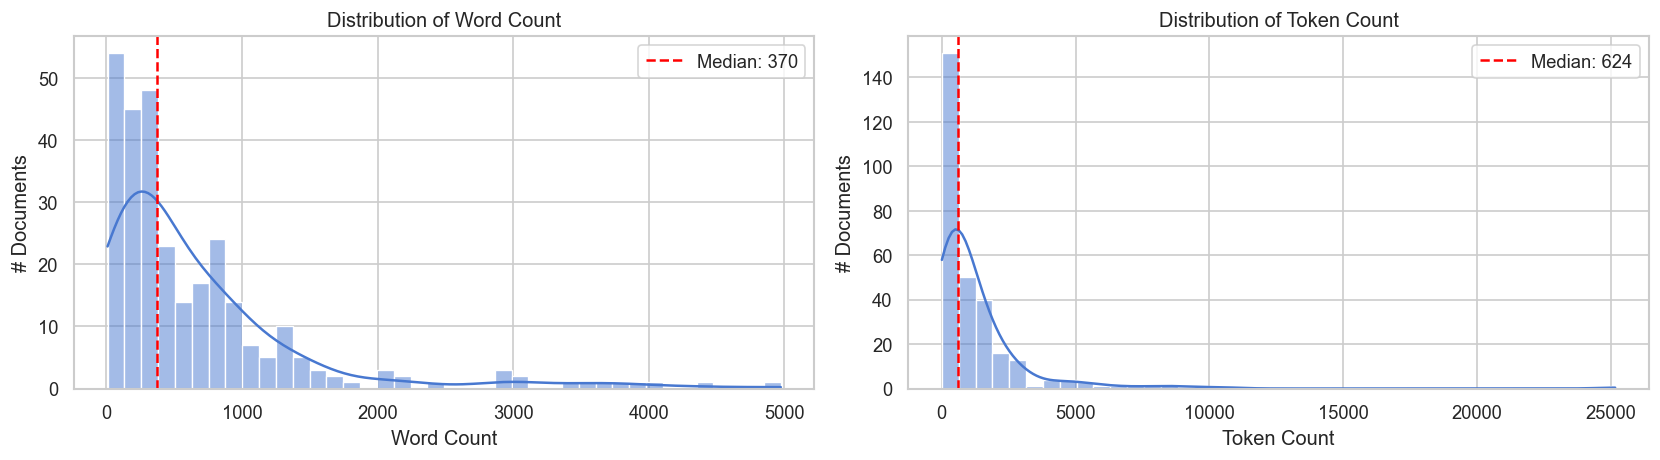

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(axes, ['word_count', 'token_count'], ['Word Count', 'Token Count']):
    sns.histplot(df[col], bins=40, ax=ax, kde=True)
    ax.set_title(f'Distribution of {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('# Documents')
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median: {df[col].median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

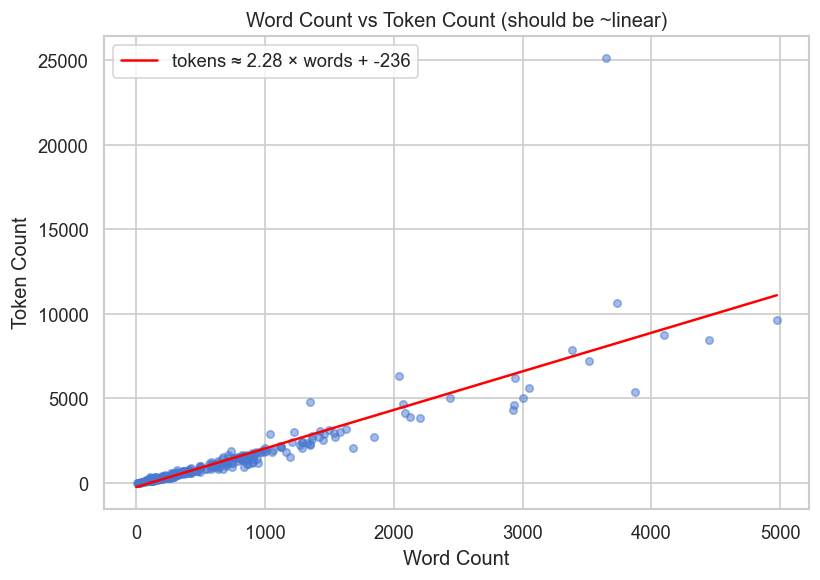

Avg tokens/word ratio: 1.71


In [9]:
# Word count vs token count scatter — sanity check
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['word_count'], df['token_count'], alpha=0.5, s=20)
ax.set_xlabel('Word Count')
ax.set_ylabel('Token Count')
ax.set_title('Word Count vs Token Count (should be ~linear)')

m, b = np.polyfit(df['word_count'], df['token_count'], 1)
x_line = np.linspace(0, df['word_count'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', label=f'tokens ≈ {m:.2f} × words + {b:.0f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Avg tokens/word ratio: {(df["token_count"] / df["word_count"].replace(0, np.nan)).mean():.2f}')

In [10]:
# Outlier docs
tiny = df[df['token_count'] < 50][['title', 'url', 'token_count']].sort_values('token_count')
giant = df[df['token_count'] > 2000][['title', 'url', 'token_count']].sort_values('token_count', ascending=False)

print(f'=== Tiny docs (< 50 tokens): {len(tiny)} ===')
print(tiny.to_string(index=False))
print()
print(f'=== Giant docs (> 2000 tokens): {len(giant)} ===')
print(giant.to_string(index=False))

=== Tiny docs (< 50 tokens): 8 ===
                     title                                                         url  token_count
                  Currency                   https://docs.celonis.com/en/currency.html           11
                    Custom                     https://docs.celonis.com/en/custom.html           11
             Miscellaneous              https://docs.celonis.com/en/miscellaneous.html           17
              Cheat Sheets               https://docs.celonis.com/en/cheat-sheets.html           22
               Aggregation                https://docs.celonis.com/en/aggregation.html           30
Machine Learning Functions https://docs.celonis.com/en/machine-learning-functions.html           30
                      Math                       https://docs.celonis.com/en/math.html           45
             Set Operators              https://docs.celonis.com/en/set-operators.html           48

=== Giant docs (> 2000 tokens): 47 ===
                         

## 2. Document Length Distribution Deep-Dive

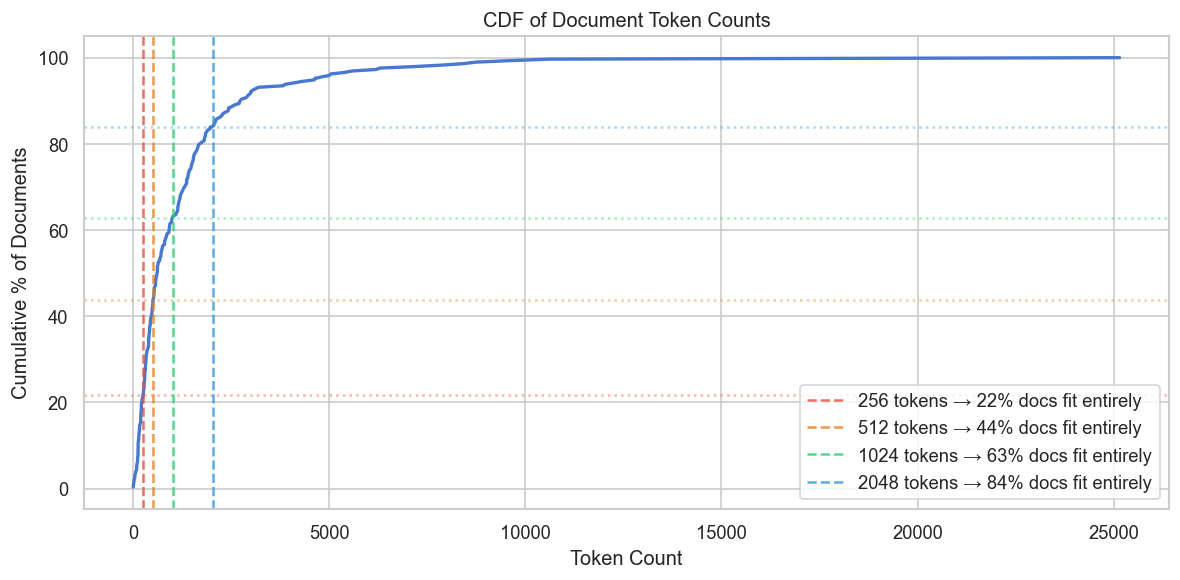

In [11]:
# Cumulative distribution with chunk size annotations
chunk_sizes = [256, 512, 1024, 2048]
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

sorted_tokens = np.sort(df['token_count'])
cdf = np.arange(1, len(sorted_tokens) + 1) / len(sorted_tokens)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_tokens, cdf * 100, linewidth=2)

for size, color in zip(chunk_sizes, colors):
    pct_below = (df['token_count'] <= size).mean() * 100
    ax.axvline(size, color=color, linestyle='--', alpha=0.8,
               label=f'{size} tokens → {pct_below:.0f}% docs fit entirely')
    ax.axhline(pct_below, color=color, linestyle=':', alpha=0.4)

ax.set_xlabel('Token Count')
ax.set_ylabel('Cumulative % of Documents')
ax.set_title('CDF of Document Token Counts')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

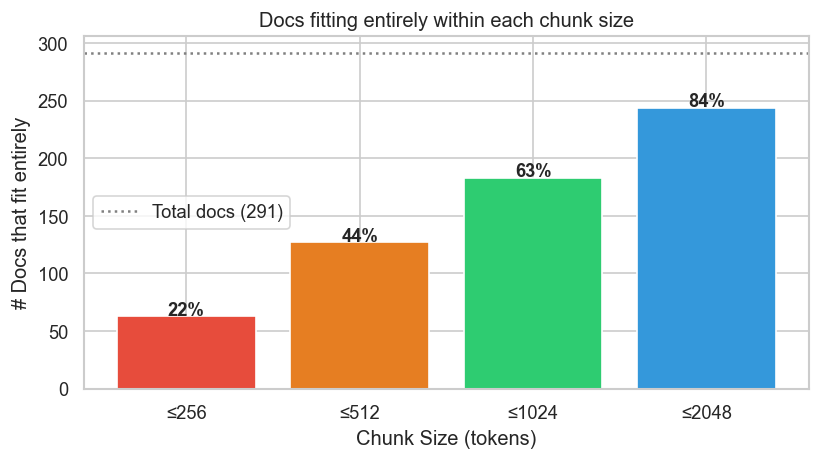

In [12]:
# Bar chart: how many docs fit entirely within common chunk sizes
fit_counts = {f'≤{s}': (df['token_count'] <= s).sum() for s in chunk_sizes}
fit_pcts = {k: v / len(df) * 100 for k, v in fit_counts.items()}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(fit_counts.keys(), fit_counts.values(), color=colors)
for bar, pct in zip(bars, fit_pcts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{pct:.0f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Chunk Size (tokens)')
ax.set_ylabel('# Docs that fit entirely')
ax.set_title('Docs fitting entirely within each chunk size')
ax.set_ylim(0, len(df) + 15)
ax.axhline(len(df), color='gray', linestyle=':', label=f'Total docs ({len(df)})')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Structural Element Analysis

Almost every page in this corpus is a **PQL function reference** with a predictable schema.
Understanding that structure is the foundation of any good chunking decision.

In [26]:
# ── 3.1  Corpus-level signal table ──────────────────────────────────────────
section_keywords = ['Description', 'Syntax', 'Result',
                    'Example', 'Warning', 'Note', 'Tips', 'Return', 'Parameters']

big = df[df['word_count'] > 200]   # exclude stubs

rows = []
for kw in section_keywords:
    count = big['full_content'].str.contains(rf'\b{kw}\b', na=False).sum()
    rows.append({
        'Section header': kw,
        'Pages containing it': count,
        '% of pages > 200w': f"{count / len(big) * 100:.0f}%",
    })

has_examples = df['full_content'].str.contains(r'[Ee]xample', na=False).sum()
has_pql_kw   = df['full_content'].str.contains(
    r'\b(SELECT|FILTER|PU_|MATCH_PROCESS|CALC_THROUGHPUT)\b', na=False).sum()

summary_rows = [
    {'Signal': 'Total pages',              'Value': f"{len(df)}"},
    {'Signal': 'Min words',               'Value': f"{int(df['word_count'].min())}"},
    {'Signal': 'Max words',               'Value': f"{int(df['word_count'].max())}"},
    {'Signal': 'Avg words',               'Value': f"{df['word_count'].mean():.0f}"},
    {'Signal': 'Median words',            'Value': f"{int(df['word_count'].median())}"},
    {'Signal': 'Pages with examples',     'Value': f"{has_examples} / {len(df)}"},
    {'Signal': 'Pages with PQL keywords', 'Value': f"{has_pql_kw} / {len(df)}"},
    {'Signal': 'Pages with errors',       'Value': f"{df['error'].notna().sum()}"},
]

print("━" * 46)
print("  CORPUS-LEVEL SIGNALS")
print("━" * 46)
print(pd.DataFrame(summary_rows).set_index('Signal').to_string())

print()
print("━" * 46)
print("  SECTION HEADER FREQUENCY  (pages > 200 words)")
print("━" * 46)
print(pd.DataFrame(rows).set_index('Section header').to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CORPUS-LEVEL SIGNALS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                             Value
Signal                            
Total pages                    291
Min words                        9
Max words                     4973
Avg words                      666
Median words                   370
Pages with examples      260 / 291
Pages with PQL keywords   84 / 291
Pages with errors                0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION HEADER FREQUENCY  (pages > 200 words)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                Pages containing it % of pages > 200w
Section header                                       
Description                     211              100%
Syntax                          177               83%
Result                          197               93%
Example                          68               32%
Warning                          48               23%
Note        

/var/folders/4q/cmnr9_td7rg21qylmx_4b9580000gn/T/ipykernel_8781/3254063190.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_pql_kw   = df['full_content'].str.contains(


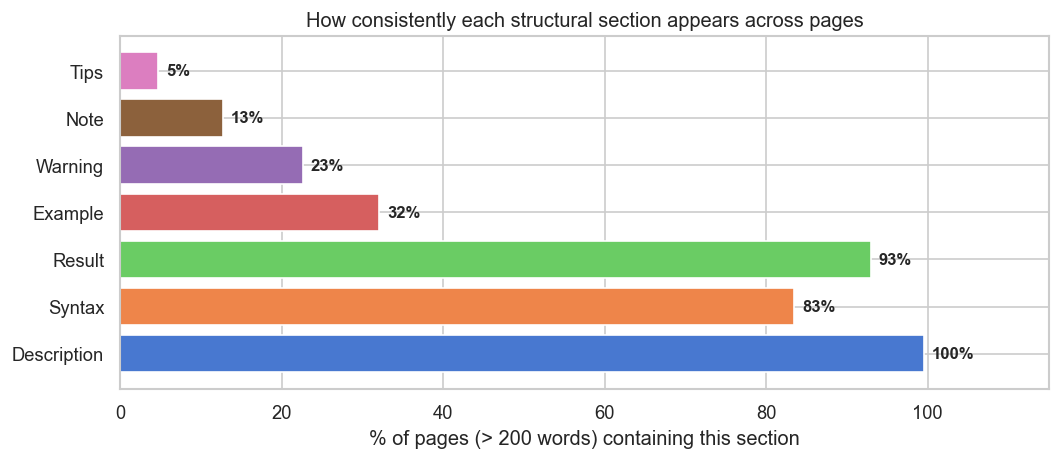

In [27]:
# ── 3.2  Section presence bar chart ─────────────────────────────────────────
section_keywords = ['Description', 'Syntax', 'Result',
                    'Example', 'Warning', 'Note', 'Tips']

present = {
    kw: big['full_content'].str.contains(rf'\b{kw}\b', na=False).mean() * 100
    for kw in section_keywords
}

fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette('muted', len(present))
bars = ax.barh(list(present.keys()), list(present.values()), color=palette)
ax.set_xlabel('% of pages (> 200 words) containing this section')
ax.set_title('How consistently each structural section appears across pages')
ax.set_xlim(0, 115)
for bar, val in zip(bars, present.values()):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# ── 3.3  Sample documents: one small, one medium, one large ─────────────────
#
# This cell lets you inspect the raw shape of a typical page at each size tier
# so it's clear what a chunker will actually be splitting.

def print_doc(row, max_chars=1200):
    sep = "─" * 60
    print(sep)
    print(f"  TITLE : {row['title']}")
    print(f"  WORDS : {row['word_count']}   TOKENS: {row['token_count']}")
    print(f"  URL   : {row['url']}")
    print(sep)
    content = row['full_content'] or ''
    print(content[:max_chars])
    if len(content) > max_chars:
        print(f"\n  … [{len(content) - max_chars} more characters] …")
    print()

# Pick one representative from each tier
small  = df[(df['word_count'] >= 50)  & (df['word_count'] < 200)].iloc[2]
medium = df[(df['word_count'] >= 400) & (df['word_count'] < 700)].iloc[0]
large  = df[df['word_count'] >= 2000].iloc[1]

print("━" * 60)
print("  TIER: SMALL  (50–200 words)  — likely fits in one chunk")
print("━" * 60)
print_doc(small)

print("━" * 60)
print("  TIER: MEDIUM  (400–700 words)  — fits in one chunk comfortably")
print("━" * 60)
print_doc(medium)

print("━" * 60)
print("  TIER: LARGE  (2000+ words)  — must be split")
print("━" * 60)
print_doc(large, max_chars=1500)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TIER: SMALL  (50–200 words)  — likely fits in one chunk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
────────────────────────────────────────────────────────────
  TITLE : INT
  WORDS : 76   TOKENS: 153
  URL   : https://docs.celonis.com/en/int.html
────────────────────────────────────────────────────────────
INT Description Celonis uses 64 bits to represent integers. It supports the range -9223372036854775808 to 9223372036854775807. Examples [1] Example with three small integer values: Query Column1 "Table1"."Values" Input Output Table1 Values : int 4 13 25 Result Column1 : int 4 13 25 [2] Example with the minimum and maximum integer values: Query Column1 "Table1"."Values" Input Output Table1 Values : int -9223372036854775808 0 9223372036854775807 Result Column1 : int -9223372036854775808 0 9223372036854775807 See also: Data Type Conversion

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TIE

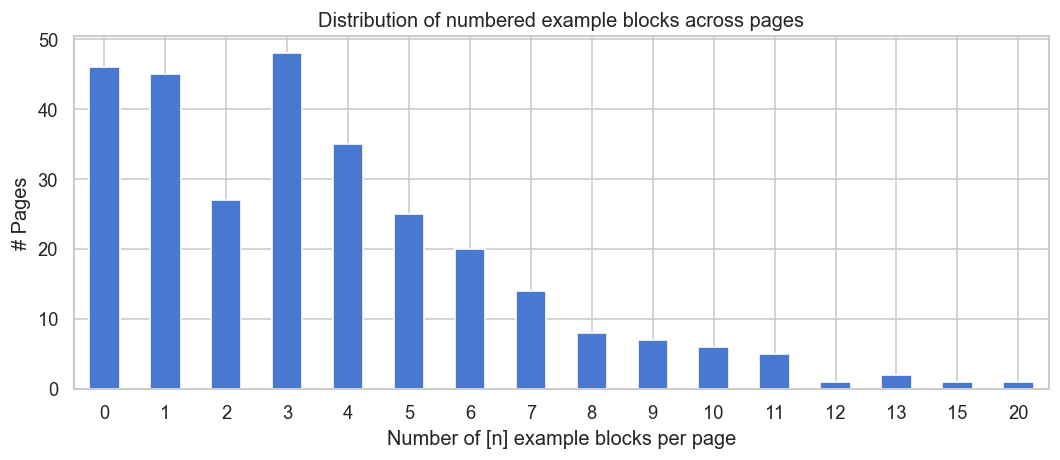

In [32]:
# ── 3.4  How many numbered examples does each page have? ────────────────────
#
# The pattern [1], [2], [3] … marks individual example blocks in the docs.
# This is the natural split boundary for large function-reference pages.

df['n_examples'] = df['full_content'].str.count(r'\[\d+\]')

example_dist = df['n_examples'].value_counts().sort_index()
# print("Number of numbered example blocks per page:")
# print(example_dist.to_string())
# print()
# print(f"Pages with 0 numbered examples : {(df['n_examples'] == 0).sum()}")
# print(f"Pages with 1+ numbered examples: {(df['n_examples'] >= 1).sum()}")
# print(f"Max examples on a single page  : {df['n_examples'].max()}  "
#       f"({df.loc[df['n_examples'].idxmax(), 'title']})")

fig, ax = plt.subplots(figsize=(9, 4))
example_dist.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_xlabel('Number of [n] example blocks per page')
ax.set_ylabel('# Pages')
ax.set_title('Distribution of numbered example blocks across pages')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. Chunking Strategy Simulation

In [20]:
CHUNK_SIZE = 512
OVERLAP = 50

def fixed_size_chunks(text, chunk_size=CHUNK_SIZE, overlap=OVERLAP):
    """Returns list of token counts for each chunk."""
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = enc.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunks.append(end - start)
        start += chunk_size - overlap
    return chunks

df['fixed_chunks'] = df['full_content'].apply(fixed_size_chunks)
df['fixed_n_chunks'] = df['fixed_chunks'].apply(len)

all_fixed_sizes = [size for chunks in df['fixed_chunks'] for size in chunks]
print(f'Fixed-size strategy ({CHUNK_SIZE} tokens, {OVERLAP} overlap):')
print(f'  Total chunks produced: {len(all_fixed_sizes)}')
print(f'  Avg chunk size: {np.mean(all_fixed_sizes):.0f} tokens')
print(f'  Chunk size range: {min(all_fixed_sizes)} – {max(all_fixed_sizes)}')

Fixed-size strategy (512 tokens, 50 overlap):
  Total chunks produced: 959
  Avg chunk size: 423 tokens
  Chunk size range: 3 – 512


In [21]:
def header_chunks(text):
    """Split on ## headers, return list of token counts per section."""
    if not isinstance(text, str) or not text.strip():
        return []
    sections = re.split(r'(?m)^(?=## )', text)
    return [len(enc.encode(s)) for s in sections if s.strip()]

df['header_chunks'] = df['full_content'].apply(header_chunks)
df['header_n_chunks'] = df['header_chunks'].apply(len)

all_header_sizes = [size for chunks in df['header_chunks'] for size in chunks]
print(f'Header-based strategy (split on ##):')
print(f'  Total chunks produced: {len(all_header_sizes)}')
print(f'  Avg chunk size: {np.mean(all_header_sizes):.0f} tokens')
print(f'  Chunk size range: {min(all_header_sizes)} – {max(all_header_sizes)}')
print(f'  Chunks > 1024 tokens: {sum(1 for s in all_header_sizes if s > 1024)} ({sum(1 for s in all_header_sizes if s > 1024)/len(all_header_sizes)*100:.1f}%)')
print(f'  Chunks < 50 tokens:   {sum(1 for s in all_header_sizes if s < 50)} ({sum(1 for s in all_header_sizes if s < 50)/len(all_header_sizes)*100:.1f}%)')

Header-based strategy (split on ##):
  Total chunks produced: 291
  Avg chunk size: 1283 tokens
  Chunk size range: 11 – 25146
  Chunks > 1024 tokens: 108 (37.1%)
  Chunks < 50 tokens:   8 (2.7%)


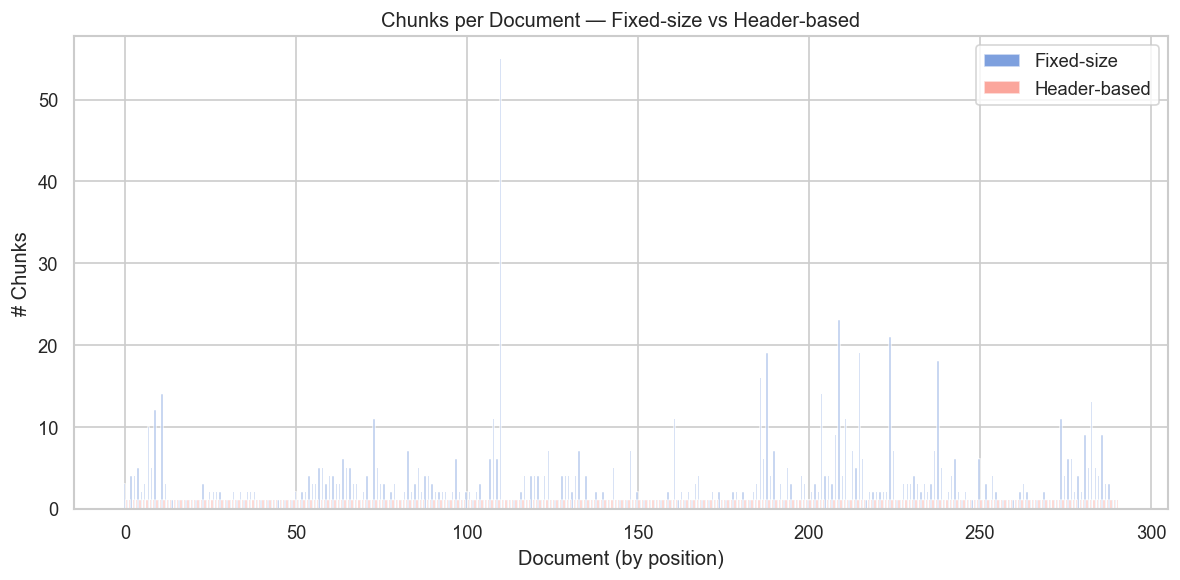

In [23]:
# Side-by-side: chunks per document
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df))
ax.bar(x - 0.3, df['fixed_n_chunks'], width=0.4, label='Fixed-size', alpha=0.7)
ax.bar(x + 0.3, df['header_n_chunks'], width=0.4, label='Header-based', alpha=0.7, color='salmon')
ax.set_xlabel('Document (by position)')
ax.set_ylabel('# Chunks')
ax.set_title('Chunks per Document — Fixed-size vs Header-based')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Chunk size variance — lower is more uniform
fixed_std = np.std(all_fixed_sizes)
header_std = np.std(all_header_sizes)
print(f'Fixed-size  — std dev of chunk sizes: {fixed_std:.0f} tokens')
print(f'Header-based — std dev of chunk sizes: {header_std:.0f} tokens')
print()

# Edge cases
print('Header-based oversized chunks (> 1024 tokens):')
oversized = []
for _, row in df.iterrows():
    for size in row['header_chunks']:
        if size > 1024:
            oversized.append({'title': row['title'], 'section_tokens': size})
print(pd.DataFrame(oversized).groupby('title')['section_tokens'].max().sort_values(ascending=False).head(10))

Fixed-size  — std dev of chunk sizes: 152 tokens
Header-based — std dev of chunk sizes: 2111 tokens

Header-based oversized chunks (> 1024 tokens):
title
WORKDAY_CALENDAR                            25146
CREATE_EVENTLOG                             10617
MATCH_PROCESS_REGEX                          9622
MERGE_EVENTLOG - MERGE_EVENTLOG_DISTINCT     8745
LINK_PATH                                    8436
TRANSIT_COLUMN                               7885
LINK_FILTER                                  7191
Catalog Tables - OCPM                        6311
BPMN_CONFORMS                                6192
Multiple Invoices per Case                   5589
Name: section_tokens, dtype: int64


## 6. Summary & Recommendations

*(Fill in after running the notebook — key observations and chosen strategy)*

### Key findings
- Majority of docs have this structure: description, syntax, and examples (+80%)
- Median page has around 370 words - 660 tokens (?)
- We need to apply a PQL dictionary to avoid splitting function names. 
- ≤256: 22%, ≤512: 44%, ≤1024: 63%, ≤2048: 84%.


### Recommendation
- ...

### Next steps
- ...